<a href="https://colab.research.google.com/github/alizasultanaesd-png/skill-morph-work/blob/main/Khulna_Barishal_Rainfall_Analysis_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ERA5 Precipitation**

In [56]:
!pip install xarray netCDF4 matplotlib
!pip install cartopy

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import pandas as pd
import sys
import xarray as xr
import geopandas as gpd


In [57]:
from google.colab import files
uploaded = files.upload()


Saving data_stream-moda_stepType-avgad.nc to data_stream-moda_stepType-avgad (2).nc


In [58]:
# Load data
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

print(ds)


<xarray.Dataset> Size: 406kB
Dimensions:     (valid_time: 60, latitude: 41, longitude: 41)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 480B 2021-01-01T06:00:00 ... 2025...
  * latitude    (latitude) float64 328B 29.0 28.75 28.5 ... 19.5 19.25 19.0
  * longitude   (longitude) float64 328B 85.0 85.25 85.5 ... 94.5 94.75 95.0
    number      int64 8B ...
    expver      (valid_time) <U4 960B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 403kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T09:15 GRIB to CDM+CF via cfgrib-0.9.1...


In [59]:
print(ds.variables)
ds_5yr = ds.sel(valid_time=slice("2021-01-01", "2025-12-31"))

Frozen({'tp': <xarray.Variable (valid_time: 60, latitude: 41, longitude: 41)> Size: 403kB
[100860 values with dtype=float32]
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1681
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0, 'number': <xarray.Variable ()> Size: 8B
[1 values with dtype=int64]
Attributes:
    long_name:      ensemble member numerical id
    units:          1
    standard_name:  realization, 'v

In [60]:
from google.colab import files
uploaded = files.upload()

Saving bgd_admin1.geojson to bgd_admin1 (1).geojson


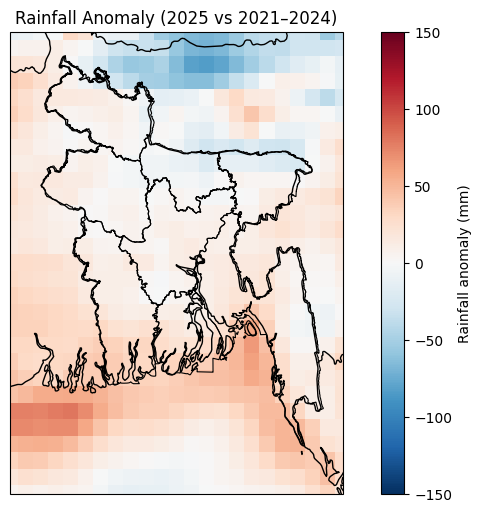

In [80]:
# =========================
# 1. Import
# =========================
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 2. Load data
# =========================
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# =========================
# 3. Conversion
# =========================
days = ds['valid_time'].dt.days_in_month
tp = ds['tp'] * 1000 * days  # mm/month

# =========================
# 4. Baseline (2021–2024)
# =========================
baseline = tp.sel(valid_time=slice("2021","2024")).groupby("valid_time.month").mean()

# =========================
# 5. 2025
# =========================
tp_2025 = tp.sel(valid_time="2025").groupby("valid_time.month").mean()

# =========================
# 6. Anomaly (2025 vs baseline)
# =========================
anom_2025 = tp.sel(valid_time="2025").mean("valid_time") - \
            tp.sel(valid_time=slice("2021","2024")).mean("valid_time")

# scale fixed to ±150
vmax = 150
vmin = -150

# =========================
# 7. Load map
# =========================
divisions = gpd.read_file("bgd_admin1.geojson")

# =========================
# 8. Plot anomaly map
# =========================
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

anom_2025.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label':'Rainfall anomaly (mm)'}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([87.5, 93, 20, 27])
divisions.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)

ax.set_title("Rainfall Anomaly (2025 vs 2021–2024)")
plt.show()


/tmp/ipykernel_27485/3006954614.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


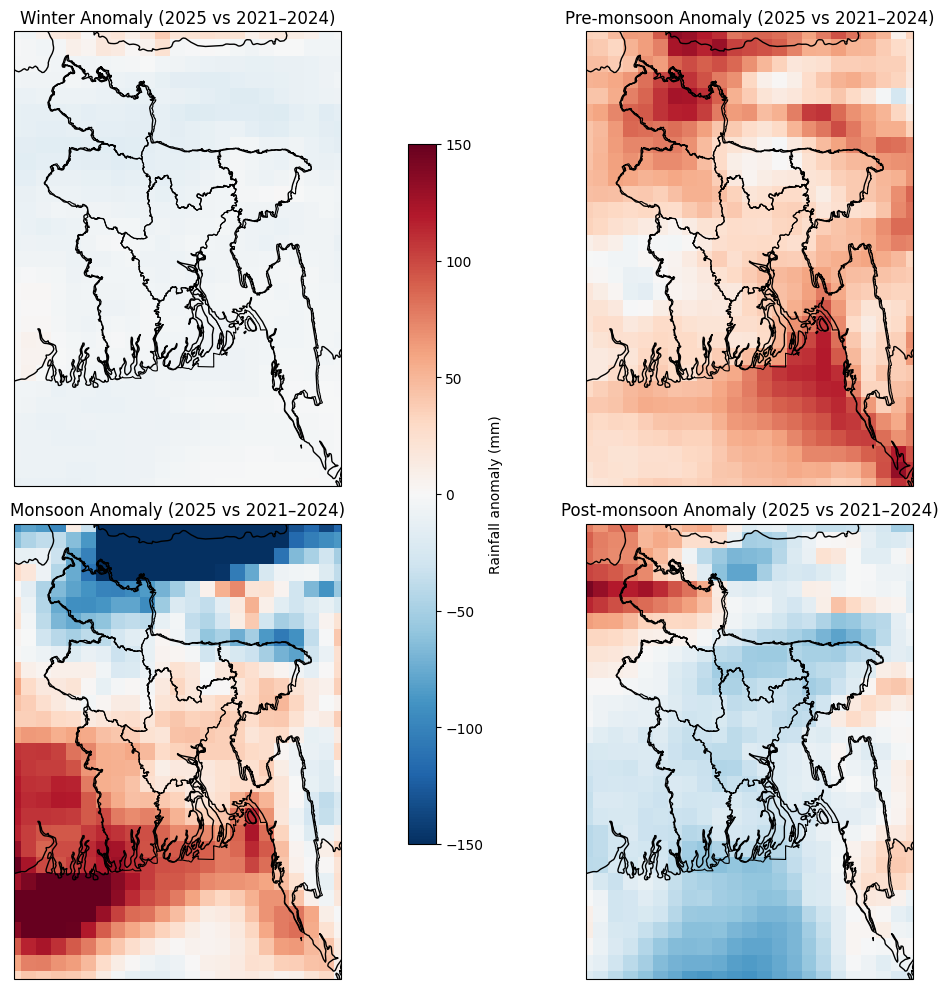

In [87]:
# =========================
# Seasonal anomaly maps with central vertical colorbar
# =========================
seasons = {
    "Winter":[1,2],
    "Pre-monsoon":[3,4,5],
    "Monsoon":[6,7,8,9],
    "Post-monsoon":[10,11]
}

fig, axes = plt.subplots(2,2, figsize=(14,10), subplot_kw={'projection':ccrs.PlateCarree()})

for ax, (season, months) in zip(axes.flat, seasons.items()):
    anom_season = tp.sel(valid_time="2025").where(tp['valid_time'].dt.month.isin(months)).mean("valid_time") - \
                  tp.sel(valid_time=slice("2021","2024")).where(tp['valid_time'].dt.month.isin(months)).mean("valid_time")
    im = anom_season.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-150,
        vmax=150,
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_extent([87.5,93,20,27])
    divisions.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    ax.set_title(f"{season} Anomaly (2025 vs 2021–2024)")

# 👉 Central vertical colorbar between subplots
cbar_ax = fig.add_axes([0.46, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label("Rainfall anomaly (mm)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_27485/2506499875.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.95,1])  # leave space at right for colorbar


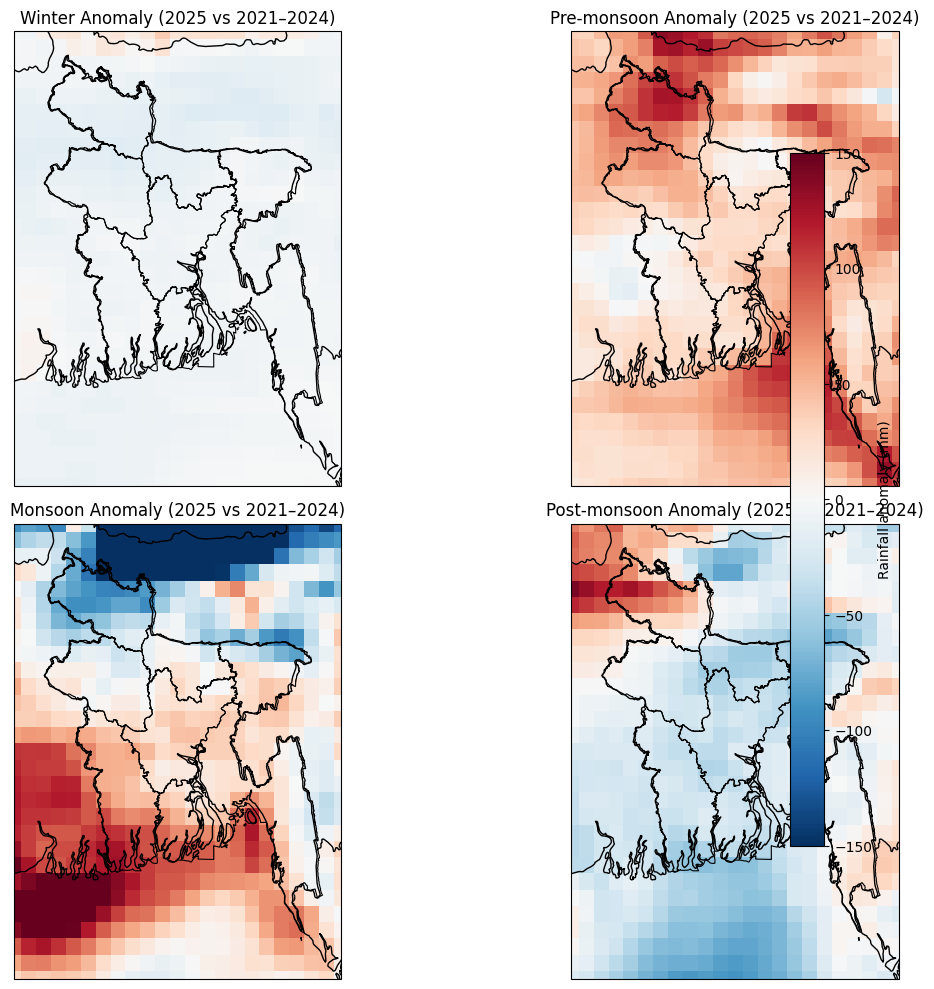

In [86]:
# =========================
# Seasonal anomaly maps with vertical side colorbar
# =========================
seasons = {
    "Winter":[1,2],
    "Pre-monsoon":[3,4,5],
    "Monsoon":[6,7,8,9],
    "Post-monsoon":[10,11]
}

fig, axes = plt.subplots(2,2, figsize=(14,10), subplot_kw={'projection':ccrs.PlateCarree()})

for ax, (season, months) in zip(axes.flat, seasons.items()):
    anom_season = tp.sel(valid_time="2025").where(tp['valid_time'].dt.month.isin(months)).mean("valid_time") - \
                  tp.sel(valid_time=slice("2021","2024")).where(tp['valid_time'].dt.month.isin(months)).mean("valid_time")
    anom_season.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-150,
        vmax=150,
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_extent([87.5,93,20,27])
    divisions.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    ax.set_title(f"{season} Anomaly (2025 vs 2021–2024)")

# 👉 Vertical colorbar at the right side (no overlap)
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-150,vmax=150)),
    ax=axes.ravel().tolist(),
    orientation='vertical',
    fraction=0.05, pad=0.02, shrink=0.9,
    label="Rainfall anomaly (mm)"
)

plt.tight_layout(rect=[0,0,0.95,1])  # leave space at right for colorbar
plt.show()


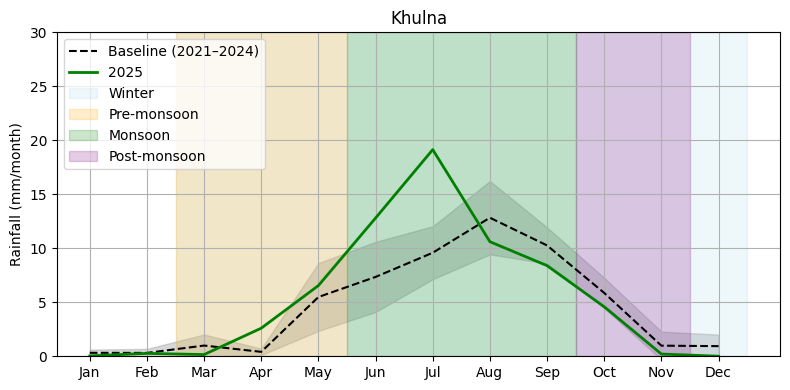

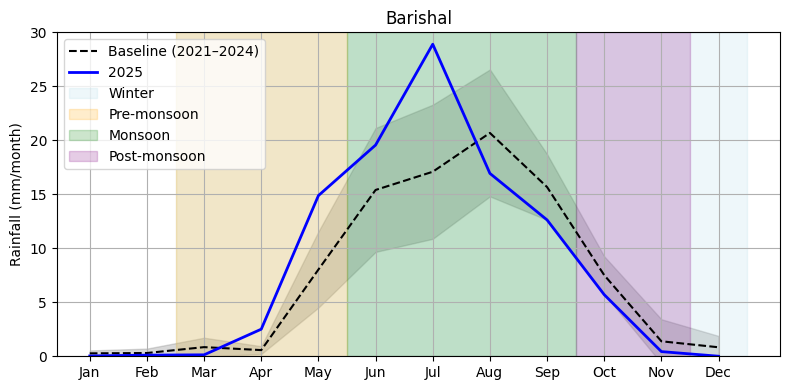

In [65]:
import matplotlib.pyplot as plt
import numpy as np

m = np.arange(1,13)

# =========================
# Khulna rainfall plot
# =========================
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(m, kh_base, '--k', label="Baseline (2021–2024)")
ax.fill_between(m, kh_base-kh_std, kh_base+kh_std, alpha=0.3, color='grey')
ax.plot(m, kh_2025, 'g', lw=2, label="2025")

# Seasonal shading
ax.axvspan(12.5, 2.5, color='lightblue', alpha=0.2, label='Winter')
ax.axvspan(2.5, 5.5, color='orange', alpha=0.2, label='Pre-monsoon')
ax.axvspan(5.5, 9.5, color='green', alpha=0.2, label='Monsoon')
ax.axvspan(9.5, 11.5, color='purple', alpha=0.2, label='Post-monsoon')

ax.set_xticks(m)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Khulna")
ax.legend(loc='upper left')
ax.grid()
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("Khulna_rainfall.png", dpi=300)
plt.show()


# =========================
# Barishal rainfall plot
# =========================
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(m, ba_base, '--k', label="Baseline (2021–2024)")
ax.fill_between(m, ba_base-ba_std, ba_base+ba_std, alpha=0.3, color='grey')
ax.plot(m, ba_2025, 'b', lw=2, label="2025")

# Seasonal shading
ax.axvspan(12.5, 2.5, color='lightblue', alpha=0.2, label='Winter')
ax.axvspan(2.5, 5.5, color='orange', alpha=0.2, label='Pre-monsoon')
ax.axvspan(5.5, 9.5, color='green', alpha=0.2, label='Monsoon')
ax.axvspan(9.5, 11.5, color='purple', alpha=0.2, label='Post-monsoon')

ax.set_xticks(m)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Barishal")
ax.legend(loc='upper left')
ax.grid()
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("Barishal_rainfall.png", dpi=300)
plt.show()


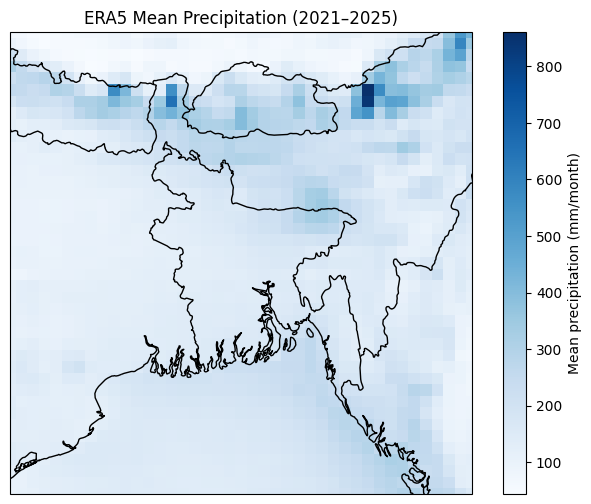

In [66]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Mean precipitation over full period
tp_mean = tp_monthly.mean(dim='valid_time')

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([85,95,19,29], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle='-')

lon, lat = np.meshgrid(ds.longitude, ds.latitude)
mesh = ax.pcolormesh(lon, lat, tp_mean, cmap='Blues', transform=ccrs.PlateCarree())
plt.colorbar(mesh, label='Mean precipitation (mm/month)')
plt.title("ERA5 Mean Precipitation (2021–2025)")
plt.show()


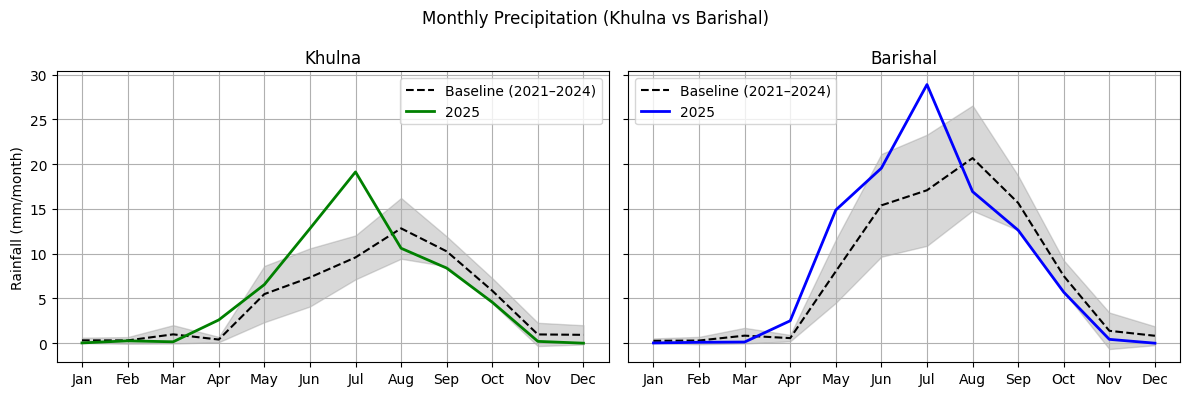

In [67]:
m = np.arange(1,13)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4), sharey=True)

# Khulna
ax1.plot(m, kh_base, '--k', label="Baseline (2021–2024)")
ax1.fill_between(m, kh_base-kh_std, kh_base+kh_std, alpha=0.3, color='grey')
ax1.plot(m, kh_2025, 'g', lw=2, label="2025")
ax1.set_xticks(m)
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.set_title("Khulna")
ax1.set_ylabel("Rainfall (mm/month)")
ax1.legend()
ax1.grid()

# Barishal
ax2.plot(m, ba_base, '--k', label="Baseline (2021–2024)")
ax2.fill_between(m, ba_base-ba_std, ba_base+ba_std, alpha=0.3, color='grey')
ax2.plot(m, ba_2025, 'b', lw=2, label="2025")
ax2.set_xticks(m)
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.set_title("Barishal")
ax2.legend()
ax2.grid()

plt.suptitle("Monthly Precipitation (Khulna vs Barishal)")
plt.tight_layout()
plt.show()


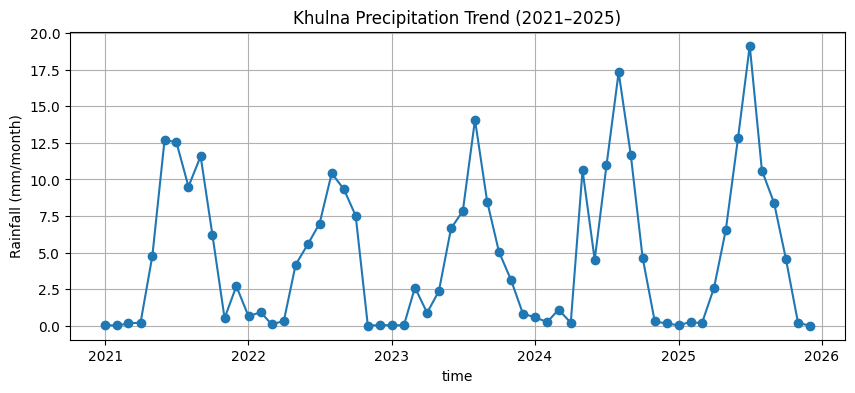

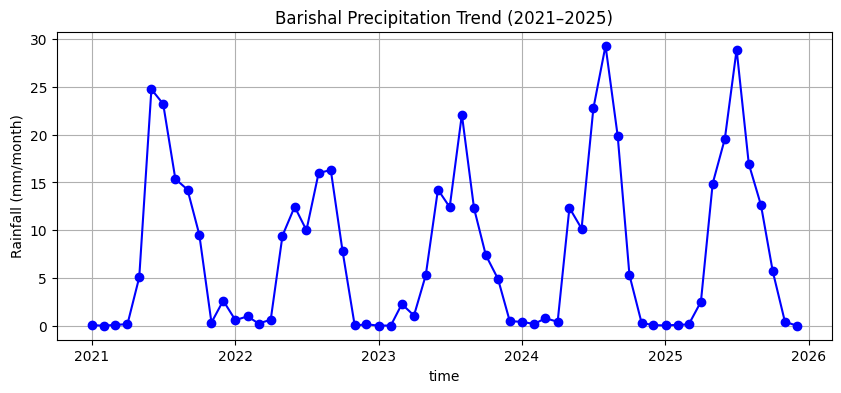

In [69]:
import matplotlib.pyplot as plt

# =========================
# Khulna long-term trend
# =========================
tp_khulna_all = (tp_monthly * mask_ds['khulna']).mean(dim=['latitude','longitude'])

fig, ax = plt.subplots(figsize=(10,4))
tp_khulna_all.plot(ax=ax, marker='o')
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Khulna Precipitation Trend (2021–2025)")
ax.grid()
plt.show()


# =========================
# Barishal long-term trend
# =========================
tp_barishal_all = (tp_monthly * mask_ds['barishal']).mean(dim=['latitude','longitude'])

fig, ax = plt.subplots(figsize=(10,4))
tp_barishal_all.plot(ax=ax, marker='o', color='b')
ax.set_ylabel("Rainfall (mm/month)")
ax.set_title("Barishal Precipitation Trend (2021–2025)")
ax.grid()
plt.show()


In [71]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def precip_workflow(ds, mask_ds):
    """
    Workflow for precipitation analysis (ERA5)
    Includes:
    1. Mean precipitation map
    2. Monthly time series (Khulna & Barishal) with seasonal shading
    3. Long-term trends
    4. Hazard months detection
    """

    # --- Convert to mm/month ---
    days_in_month = ds['valid_time'].dt.days_in_month
    tp_monthly = ds['tp'] * 1000 * days_in_month.broadcast_like(ds['tp'])

    # --- Mean precipitation map ---
    tp_mean = tp_monthly.mean(dim='valid_time')
    fig = plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([85,95,19,29], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle='-')
    lon, lat = np.meshgrid(ds.longitude, ds.latitude)
    mesh = ax.pcolormesh(lon, lat, tp_mean, cmap='Blues', transform=ccrs.PlateCarree())
    plt.colorbar(mesh, label='Mean precipitation (mm/month)')
    plt.title("ERA5 Mean Precipitation (2021–2025)")
    plt.show()

    # --- Baseline & 2025 ---
    baseline = tp_monthly.sel(valid_time=slice("2021-01-01","2024-12-31")) \
                 .groupby("valid_time.month").mean()
    std = tp_monthly.sel(valid_time=slice("2021-01-01","2024-12-31")) \
                 .groupby("valid_time.month").std()
    tp_2025 = tp_monthly.sel(valid_time=slice("2025-01-01","2025-12-31")) \
                 .groupby("valid_time.month").mean()

    # --- Region averages ---
    kh_base = (baseline * mask_ds['khulna']).mean(dim=['latitude','longitude']).values
    kh_std  = (std * mask_ds['khulna']).mean(dim=['latitude','longitude']).values
    kh_2025 = (tp_2025 * mask_ds['khulna']).mean(dim=['latitude','longitude']).values

    ba_base = (baseline * mask_ds['barishal']).mean(dim=['latitude','longitude']).values
    ba_std  = (std * mask_ds['barishal']).mean(dim=['latitude','longitude']).values
    ba_2025 = (tp_2025 * mask_ds['barishal']).mean(dim=['latitude','longitude']).values

    m = np.arange(1,13)

    # --- Monthly time series with seasonal shading ---
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4), sharey=True)

    # Khulna
    ax1.plot(m, kh_base, '--k', label="Baseline (2021–2024)")
    ax1.fill_between(m, kh_base-kh_std, kh_base+kh_std, alpha=0.3, color='grey')
    ax1.plot(m, kh_2025, 'g', lw=2, label="2025")
    # Seasonal shading
    ax1.axvspan(12.5, 2.5, color='lightblue', alpha=0.2, label='Winter')
    ax1.axvspan(2.5, 5.5, color='orange', alpha=0.2, label='Pre-monsoon')
    ax1.axvspan(5.5, 9.5, color='green', alpha=0.2, label='Monsoon')
    ax1.axvspan(9.5, 11.5, color='purple', alpha=0.2, label='Post-monsoon')
    ax1.set_xticks(m)
    ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax1.set_title("Khulna")
    ax1.set_ylabel("Rainfall (mm/month)")
    ax1.legend(); ax1.grid()

    # Barishal
    ax2.plot(m, ba_base, '--k', label="Baseline (2021–2024)")
    ax2.fill_between(m, ba_base-ba_std, ba_base+ba_std, alpha=0.3, color='grey')
    ax2.plot(m, ba_2025, 'b', lw=2, label="2025")
    # Seasonal shading
    ax2.axvspan(12.5, 2.5, color='lightblue', alpha=0.2, label='Winter')
    ax2.axvspan(2.5, 5.5, color='orange', alpha=0.2, label='Pre-monsoon')
    ax2.axvspan(5.5, 9.5, color='green', alpha=0.2, label='Monsoon')
    ax2.axvspan(9.5, 11.5, color='purple', alpha=0.2, label='Post-monsoon')
    ax2.set_xticks(m)
    ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax2.set_title("Barishal")
    ax2.legend(); ax2.grid()

    plt.suptitle("Monthly Precipitation (Khulna vs Barishal)")
    plt.tight_layout()
    plt.show()

    # --- Long-term trends ---
    tp_khulna_all = (tp_monthly * mask_ds['khulna']).mean(dim=['latitude','longitude'])
    tp_barishal_all = (tp_monthly * mask_ds['barishal']).mean(dim=['latitude','longitude'])

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,8))
    tp_khulna_all.plot(ax=ax1, marker='o', color='g')
    ax1.set_title("Khulna Precipitation Trend (2021–2025)")
    ax1.set_ylabel("Rainfall (mm/month)"); ax1.grid()

    tp_barishal_all.plot(ax=ax2, marker='o', color='b')
    ax2.set_title("Barishal Precipitation Trend (2021–2025)")
    ax2.set_ylabel("Rainfall (mm/month)"); ax2.grid()

    plt.tight_layout()
    plt.show()

    # --- Hazard months detection ---
    hazard_months_khulna = m[kh_2025 > (kh_base + kh_std)]
    hazard_months_barishal = m[ba_2025 > (ba_base + ba_std)]

    print("Khulna hazard months (high rainfall):", hazard_months_khulna)
    print("Barishal hazard months (high rainfall):", hazard_months_barishal)


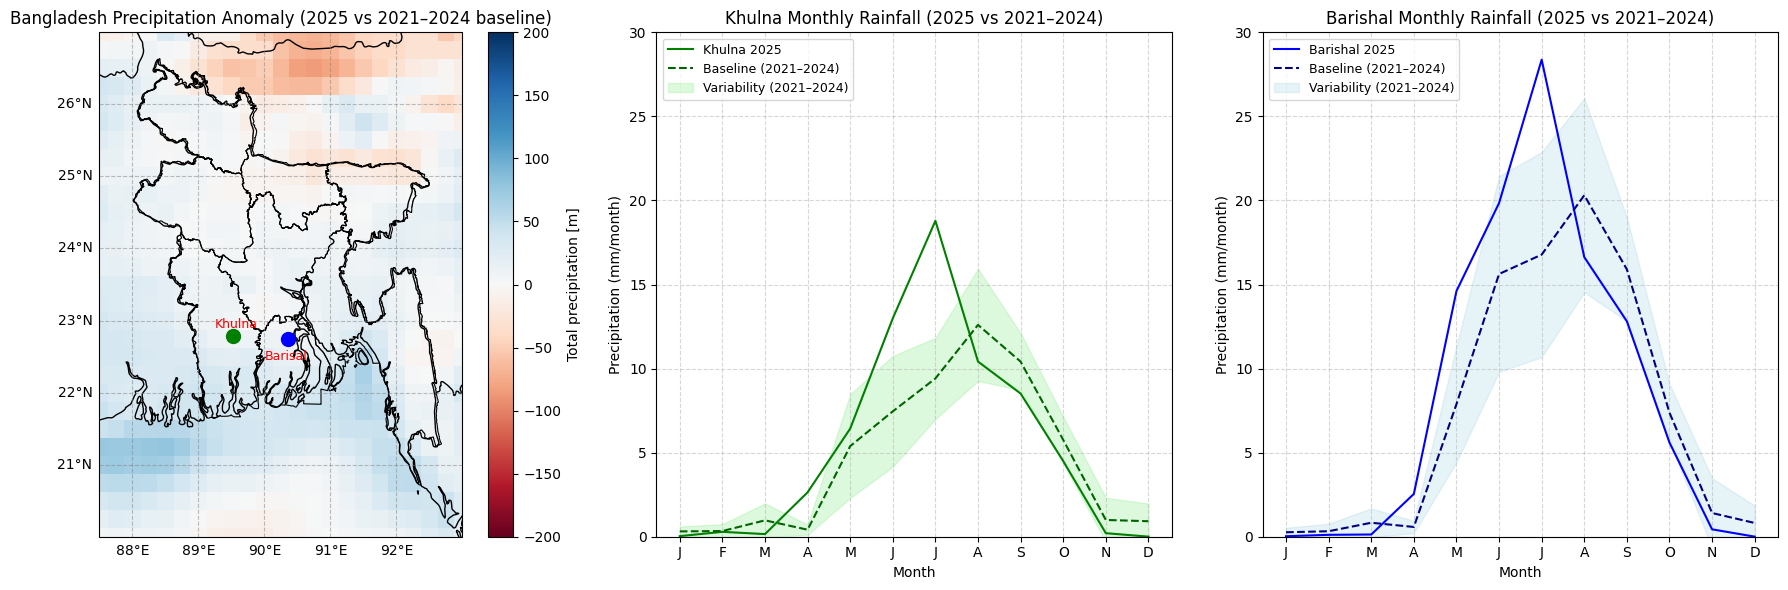

In [61]:

import geopandas as gpd

# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# Convert ERA5 'tp' (m/day) → mm/month
tp = ds['tp'] * 1000 * 365.25 / 12.0

# --- Baseline climatology (2021–2024) ---
baseline = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").mean(dim="valid_time")
std = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").std(dim="valid_time")

# --- 2025 monthly mean ---
tp_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).groupby("valid_time.month").mean(dim="valid_time")

# --- Region masks ---
lats = ds.latitude.values
lons = ds.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

mask_khulna = ((lat2d >= 21.5) & (lat2d <= 23.0) &
               (lon2d >= 88.5) & (lon2d <= 90.0)).astype(int)

mask_barishal = ((lat2d >= 21.0) & (lat2d <= 23.0) &
                 (lon2d >= 90.0) & (lon2d <= 91.5)).astype(int)

mask_ds = xr.Dataset(
    {
        "mask_khulna": (("latitude","longitude"), mask_khulna),
        "mask_barishal": (("latitude","longitude"), mask_barishal),
    },
    coords={"latitude": lats, "longitude": lons}
)

# --- Region-wise averages ---
tp_khulna_baseline = (baseline * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_std = (std * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_2025 = (tp_2025 * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])

tp_barishal_baseline = (baseline * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_std = (std * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_2025 = (tp_2025 * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])

# --- Anomaly map (2025 vs baseline) ---
anom_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).mean(dim="valid_time") - \
            tp.sel(valid_time=slice("2021-01-01","2024-12-31")).mean(dim="valid_time")

# --- Load Bangladesh division boundaries ---
divisions = gpd.read_file("bgd_admin1.geojson")

# --- Plot layout ---
fig = plt.figure(figsize=(18,6))

# Left panel: Map
ax1 = fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
anom_2025.plot(ax=ax1, transform=ccrs.PlateCarree(),
               cmap="RdBu", vmin=-200, vmax=200, add_colorbar=True)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS)
ax1.set_extent([87.5, 93, 20, 27], crs=ccrs.PlateCarree())

# Add division boundaries
divisions.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.8, transform=ccrs.PlateCarree())

# Add gridlines
gl = ax1.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add city markers (stars) with shifted labels
ax1.plot(89.53, 22.78, marker="o", color="green", markersize=10, transform=ccrs.PlateCarree())
ax1.text(89.24, 22.90, "Khulna", color="red", fontsize=9, transform=ccrs.PlateCarree())
ax1.plot(90.36, 22.75, marker="o", color="blue", markersize=10, transform=ccrs.PlateCarree())
ax1.text(90.00, 22.45, "Barisal", color="red", fontsize=9, transform=ccrs.PlateCarree())
# Middle panel: Khulna

ax1.set_title("Bangladesh Precipitation Anomaly (2025 vs 2021–2024 baseline)")

# Middle panel: Khulna
ax2 = fig.add_subplot(1,3,2)
months = np.arange(1,13)
ax2.plot(months, tp_khulna_2025, color="green", label="Khulna 2025")
ax2.plot(months, tp_khulna_baseline, color="darkgreen", linestyle="--", label="Baseline (2021–2024)")
ax2.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Variability (2021–2024)")
ax2.set_xticks(months)
ax2.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax2.set_title("Khulna Monthly Rainfall (2025 vs 2021–2024)")
ax2.set_ylabel("Precipitation (mm/month)")
ax2.set_xlabel("Month")
ax2.legend(loc="upper left", fontsize=9, frameon=True)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.set_ylim(0, 30)

# Right panel: Barishal
ax3 = fig.add_subplot(1,3,3)
ax3.plot(months, tp_barishal_2025, color="blue", label="Barishal 2025")
ax3.plot(months, tp_barishal_baseline, color="navy", linestyle="--", label="Baseline (2021–2024)")
ax3.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Variability (2021–2024)")
ax3.set_xticks(months)
ax3.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax3.set_title("Barishal Monthly Rainfall (2025 vs 2021–2024)")
ax3.set_ylabel("Precipitation (mm/month)")
ax3.set_xlabel("Month")
ax3.legend(loc="upper left", fontsize=9, frameon=True)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("bangladesh_precip_anomaly.png", dpi=300)
plt.show()


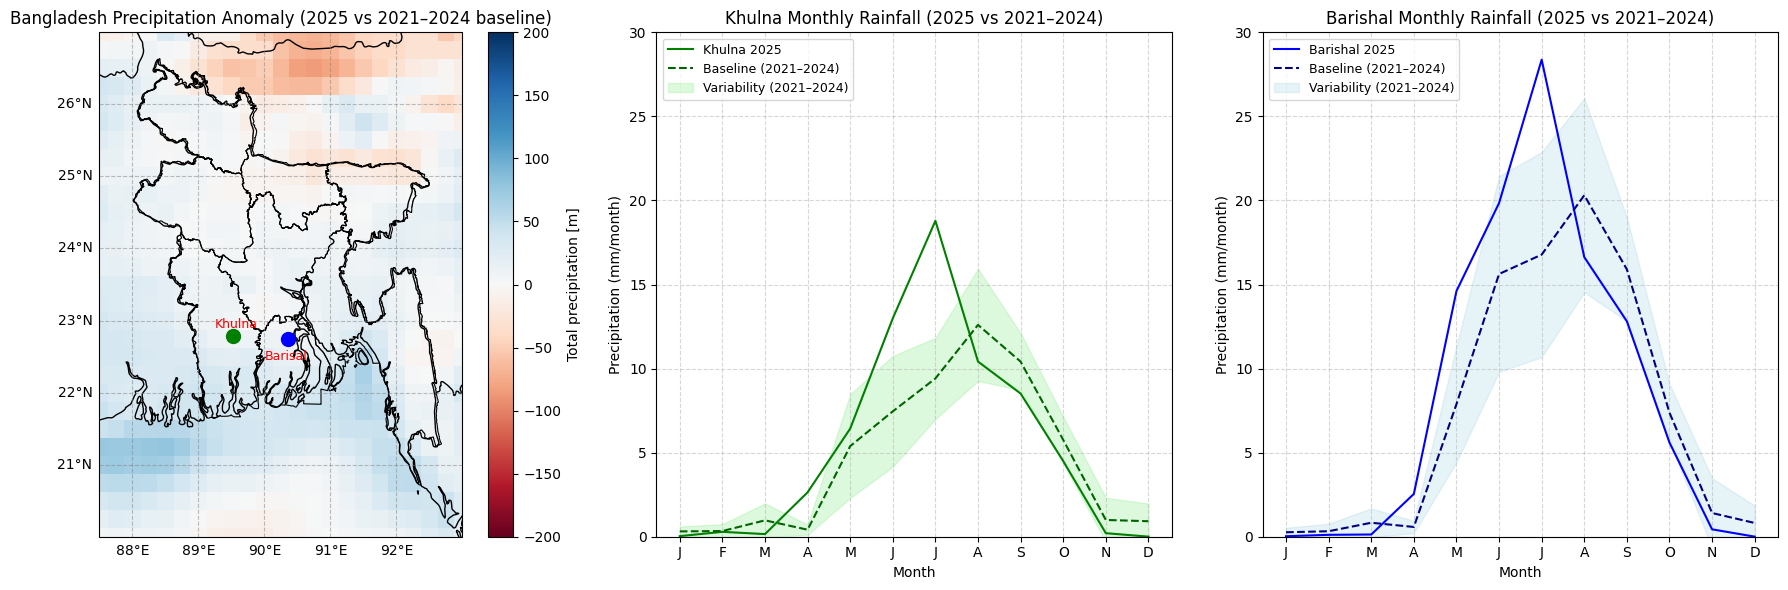

In [ ]:


# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# Convert ERA5 'tp' (m/day) → mm/month
tp = ds['tp'] * 1000 * 365.25 / 12.0

# --- Baseline climatology (2021–2024) ---
baseline = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").mean(dim="valid_time")
std = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").std(dim="valid_time")

# --- 2025 monthly mean ---
tp_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).groupby("valid_time.month").mean(dim="valid_time")

# --- Region masks ---
lats = ds.latitude.values
lons = ds.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

mask_khulna = ((lat2d >= 21.5) & (lat2d <= 23.0) &
               (lon2d >= 88.5) & (lon2d <= 90.0)).astype(int)

mask_barishal = ((lat2d >= 21.0) & (lat2d <= 23.0) &
                 (lon2d >= 90.0) & (lon2d <= 91.5)).astype(int)

mask_ds = xr.Dataset(
    {
        "mask_khulna": (("latitude","longitude"), mask_khulna),
        "mask_barishal": (("latitude","longitude"), mask_barishal),
    },
    coords={"latitude": lats, "longitude": lons}
)

# --- Region-wise averages ---
tp_khulna_baseline = (baseline * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_std = (std * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_2025 = (tp_2025 * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])

tp_barishal_baseline = (baseline * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_std = (std * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_2025 = (tp_2025 * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])

# --- Anomaly map (2025 vs baseline) ---
anom_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).mean(dim="valid_time") - \
            tp.sel(valid_time=slice("2021-01-01","2024-12-31")).mean(dim="valid_time")

# --- Load Bangladesh division boundaries ---
divisions = gpd.read_file("bgd_admin1.geojson")

# --- Plot layout ---
fig = plt.figure(figsize=(18,6))

# Left panel: Map
ax1 = fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
anom_2025.plot(ax=ax1, transform=ccrs.PlateCarree(),
               cmap="RdBu", vmin=-200, vmax=200, add_colorbar=True)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS)
ax1.set_extent([87.5, 93, 20, 27], crs=ccrs.PlateCarree())

# Add division boundaries
divisions.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.8, transform=ccrs.PlateCarree())

# Add gridlines
gl = ax1.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add city markers (stars) with shifted labels
ax1.plot(89.53, 22.78, marker="o", color="green", markersize=10, transform=ccrs.PlateCarree())
ax1.text(89.24, 22.90, "Khulna", color="red", fontsize=9, transform=ccrs.PlateCarree())
ax1.plot(90.36, 22.75, marker="o", color="blue", markersize=10, transform=ccrs.PlateCarree())
ax1.text(90.00, 22.45, "Barisal", color="red", fontsize=9, transform=ccrs.PlateCarree())
# Middle panel: Khulna

ax1.set_title("Bangladesh Precipitation Anomaly (2025 vs 2021–2024 baseline)")

# Middle panel: Khulna
ax2 = fig.add_subplot(1,3,2)
months = np.arange(1,13)
ax2.plot(months, tp_khulna_2025, color="green", label="Khulna 2025")
ax2.plot(months, tp_khulna_baseline, color="darkgreen", linestyle="--", label="Baseline (2021–2024)")
ax2.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Variability (2021–2024)")
ax2.set_xticks(months)
ax2.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax2.set_title("Khulna Monthly Rainfall (2025 vs 2021–2024)")
ax2.set_ylabel("Precipitation (mm/month)")
ax2.set_xlabel("Month")
ax2.legend(loc="upper left", fontsize=9, frameon=True)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.set_ylim(0, 30)

# Right panel: Barishal
ax3 = fig.add_subplot(1,3,3)
ax3.plot(months, tp_barishal_2025, color="blue", label="Barishal 2025")
ax3.plot(months, tp_barishal_baseline, color="navy", linestyle="--", label="Baseline (2021–2024)")
ax3.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Variability (2021–2024)")
ax3.set_xticks(months)
ax3.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax3.set_title("Barishal Monthly Rainfall (2025 vs 2021–2024)")
ax3.set_ylabel("Precipitation (mm/month)")
ax3.set_xlabel("Month")
ax3.legend(loc="upper left", fontsize=9, frameon=True)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("bangladesh_precip_anomaly.png", dpi=300)
plt.show()


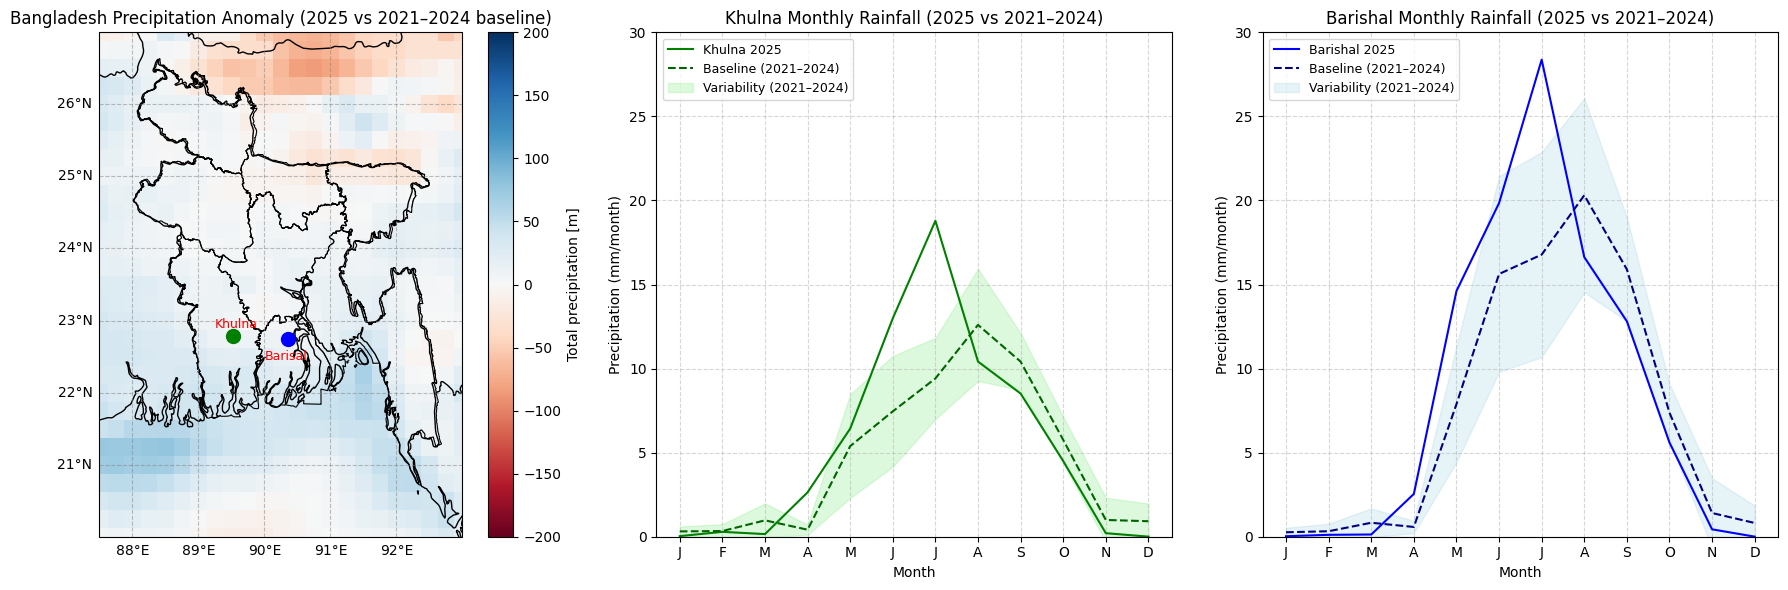

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# Convert ERA5 'tp' (m/day) → mm/month
tp = ds['tp'] * 1000 * 365.25 / 12.0

# --- Baseline climatology (2021–2024) ---
baseline = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").mean(dim="valid_time")
std = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").std(dim="valid_time")

# --- 2025 monthly mean ---
tp_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).groupby("valid_time.month").mean(dim="valid_time")

# --- Region masks ---
lats = ds.latitude.values
lons = ds.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

mask_khulna = ((lat2d >= 21.5) & (lat2d <= 23.0) &
               (lon2d >= 88.5) & (lon2d <= 90.0)).astype(int)

mask_barishal = ((lat2d >= 21.0) & (lat2d <= 23.0) &
                 (lon2d >= 90.0) & (lon2d <= 91.5)).astype(int)

mask_ds = xr.Dataset(
    {
        "mask_khulna": (("latitude","longitude"), mask_khulna),
        "mask_barishal": (("latitude","longitude"), mask_barishal),
    },
    coords={"latitude": lats, "longitude": lons}
)

# --- Region-wise averages ---
tp_khulna_baseline = (baseline * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_std = (std * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_2025 = (tp_2025 * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])

tp_barishal_baseline = (baseline * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_std = (std * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_2025 = (tp_2025 * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])

# --- Anomaly map (2025 vs baseline) ---
anom_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).mean(dim="valid_time") - \
            tp.sel(valid_time=slice("2021-01-01","2024-12-31")).mean(dim="valid_time")

# --- Load Bangladesh division boundaries ---
divisions = gpd.read_file("bgd_admin1.geojson")

# --- Plot layout ---
fig = plt.figure(figsize=(18,6))

# Left panel: Map
ax1 = fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
anom_2025.plot(ax=ax1, transform=ccrs.PlateCarree(),
               cmap="RdBu", vmin=-200, vmax=200, add_colorbar=True)
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS)
ax1.set_extent([87.5, 93, 20, 27], crs=ccrs.PlateCarree())

# Add division boundaries
divisions.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.8, transform=ccrs.PlateCarree())

# Add gridlines
gl = ax1.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add city markers (stars) with shifted labels
ax1.plot(89.53, 22.78, marker="o", color="green", markersize=10, transform=ccrs.PlateCarree())
ax1.text(89.24, 22.90, "Khulna", color="red", fontsize=9, transform=ccrs.PlateCarree())
ax1.plot(90.36, 22.75, marker="o", color="blue", markersize=10, transform=ccrs.PlateCarree())
ax1.text(90.00, 22.45, "Barisal", color="red", fontsize=9, transform=ccrs.PlateCarree())
# Middle panel: Khulna

ax1.set_title("Bangladesh Precipitation Anomaly (2025 vs 2021–2024 baseline)")

# Middle panel: Khulna
ax2 = fig.add_subplot(1,3,2)
months = np.arange(1,13)
ax2.plot(months, tp_khulna_2025, color="green", label="Khulna 2025")
ax2.plot(months, tp_khulna_baseline, color="darkgreen", linestyle="--", label="Baseline (2021–2024)")
ax2.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Variability (2021–2024)")
ax2.set_xticks(months)
ax2.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax2.set_title("Khulna Monthly Rainfall (2025 vs 2021–2024)")
ax2.set_ylabel("Precipitation (mm/month)")
ax2.set_xlabel("Month")
ax2.legend(loc="upper left", fontsize=9, frameon=True)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.set_ylim(0, 30)

# Right panel: Barishal
ax3 = fig.add_subplot(1,3,3)
ax3.plot(months, tp_barishal_2025, color="blue", label="Barishal 2025")
ax3.plot(months, tp_barishal_baseline, color="navy", linestyle="--", label="Baseline (2021–2024)")
ax3.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Variability (2021–2024)")
ax3.set_xticks(months)
ax3.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax3.set_title("Barishal Monthly Rainfall (2025 vs 2021–2024)")
ax3.set_ylabel("Precipitation (mm/month)")
ax3.set_xlabel("Month")
ax3.legend(loc="upper left", fontsize=9, frameon=True)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("bangladesh_precip_anomaly.png", dpi=300)
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
filename = "data_stream-moda_stepType-avgad.nc"
ds = xr.open_dataset(filename)
print(ds)

In [ ]:
# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")
tp = ds['tp']  # total precipitation
df = tp.to_dataframe().reset_index()

# --- 1. Compute baseline (2020–2023) and 2024 anomaly ---
baseline = tp.sel(valid_time=slice("2020-01-01", "2023-12-31")).mean(dim="valid_time")
tp_2024 = tp.sel(valid_time=slice("2024-01-01", "2024-12-31")).mean(dim="valid_time")
anomaly = tp_2024 - baseline
print(df.head(20))

# Plot anomaly map
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
anomaly.plot(ax=ax, cmap="RdBu", cbar_kwargs={'label': 'Total precipitation anomaly [m]'})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([85, 95, 19, 29], crs=ccrs.PlateCarree())
# Add latitude/longitude grid lines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False   # hide top labels
gl.right_labels = False # hide right labels
ax.set_title("Bangladesh Precipitation Anomaly (2024 vs 2020–2023 baseline)")
plt.show()



# --- 2. Time series for specific locations ---
def monthly_timeseries(ds, lat, lon, start, end):
    """Extract monthly mean precipitation for a given lat/lon and time range."""
    point = ds.sel(latitude=lat, longitude=lon, method="nearest")
    return point.sel(valid_time=slice(start, end)).groupby("valid_time.month").mean()

# Khulna (~22.78N, 89.53E)
khulna_baseline = monthly_timeseries(tp, 22.78, 89.53, "2020-01-01", "2023-12-31")
khulna_2024 = monthly_timeseries(tp, 22.78, 89.53, "2024-01-01", "2024-12-31")

# Barishal (~22.75N, 90.36E)
barishal_baseline = monthly_timeseries(tp, 22.75, 90.36, "2020-01-01", "2023-12-31")
barishal_2024 = monthly_timeseries(tp, 22.75, 90.36, "2024-01-01", "2024-12-31")

# Plot Khulna
plt.figure(figsize=(8,4))
plt.plot(khulna_2024.month, khulna_2024, label="Khulna 2024", color="green")
plt.plot(khulna_baseline.month, khulna_baseline, linestyle="--", label="Baseline (2020–2023)", color="darkgreen")
plt.fill_between(khulna_baseline.month, khulna_baseline*0.8, khulna_baseline*1.2, color="lightgreen", alpha=0.3, label="Variability")
plt.title("Khulna Monthly Rainfall (2024 vs 2020–2023)")
plt.xlabel("Month")
plt.ylabel("Precipitation (m/month)")
plt.legend()
plt.show()

# Plot Barishal
plt.figure(figsize=(8,4))
plt.plot(barishal_2024.month, barishal_2024, label="Barishal 2024", color="blue")
plt.plot(barishal_baseline.month, barishal_baseline, linestyle="--", label="Baseline (2020–2023)", color="darkblue")
plt.fill_between(barishal_baseline.month, barishal_baseline*0.8, barishal_baseline*1.2, color="lightblue", alpha=0.3, label="Variability")
plt.title("Barishal Monthly Rainfall (2024 vs 2020–2023)")
plt.xlabel("Month")
plt.ylabel("Precipitation (m/month)")
plt.legend()
plt.show()


            valid_time  latitude  longitude  number expver        tp
0  2021-01-01 06:00:00      29.0      85.00       0   0001  0.000359
1  2021-01-01 06:00:00      29.0      85.25       0   0001  0.000631
2  2021-01-01 06:00:00      29.0      85.50       0   0001  0.000420
3  2021-01-01 06:00:00      29.0      85.75       0   0001  0.000282
4  2021-01-01 06:00:00      29.0      86.00       0   0001  0.000212
5  2021-01-01 06:00:00      29.0      86.25       0   0001  0.000204
6  2021-01-01 06:00:00      29.0      86.50       0   0001  0.000149
7  2021-01-01 06:00:00      29.0      86.75       0   0001  0.000111
8  2021-01-01 06:00:00      29.0      87.00       0   0001  0.000109
9  2021-01-01 06:00:00      29.0      87.25       0   0001  0.000113
10 2021-01-01 06:00:00      29.0      87.50       0   0001  0.000061
11 2021-01-01 06:00:00      29.0      87.75       0   0001  0.000097
12 2021-01-01 06:00:00      29.0      88.00       0   0001  0.000111
13 2021-01-01 06:00:00      29.0  

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# Convert ERA5 'tp' (m/day) → mm/month
tp = ds['tp'] * 1000 * 365.25 / 12.0

# --- Baseline climatology (2021–2024) ---
baseline = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").mean(dim="valid_time")
std = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").std(dim="valid_time")

# --- 2025 monthly mean ---
tp_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).groupby("valid_time.month").mean(dim="valid_time")

# --- Region masks ---
lats = ds.latitude.values
lons = ds.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

mask_khulna = ((lat2d >= 21.5) & (lat2d <= 23.0) &
               (lon2d >= 88.5) & (lon2d <= 90.0)).astype(int)

mask_barishal = ((lat2d >= 21.0) & (lat2d <= 23.0) &
                 (lon2d >= 90.0) & (lon2d <= 91.5)).astype(int)

mask_ds = xr.Dataset(
    {
        "mask_khulna": (("latitude","longitude"), mask_khulna),
        "mask_barishal": (("latitude","longitude"), mask_barishal),
    },
    coords={"latitude": lats, "longitude": lons}
)

# --- Region-wise averages ---

tp_khulna_baseline = (baseline * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_std = (std * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_2025 = (tp_2025 * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])

tp_barishal_baseline = (baseline * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_std = (std * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_2025 = (tp_2025 * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])

# --- Anomaly map (2025 vs baseline) ---
anom_2025 = tp.sel(valid_time=slice("2025-01-01","2025-12-31")).mean(dim="valid_time") - \
            tp.sel(valid_time=slice("2021-01-01","2024-12-31")).mean(dim="valid_time")

# --- Load Bangladesh division boundaries ---
divisions = gpd.read_file("bgd_admin1.geojson")

# --- Plot layout ---
fig = plt.figure(figsize=(18,6))

# Left panel: Map
ax1 = fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
anom_2025.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap="RdBu",
    vmin=-200,
    vmax=200,
    add_colorbar=True,
    cbar_kwargs={"label": "Precipitation anomaly (mm/month)"}
)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS)
ax1.set_extent([87.5, 93, 20, 27], crs=ccrs.PlateCarree())

# Add division boundaries
divisions.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.8, transform=ccrs.PlateCarree())

# Add gridlines
gl = ax1.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add city markers (stars) with shifted labels
ax1.plot(89.53, 22.78, marker="o", color="green", markersize=10, transform=ccrs.PlateCarree())
ax1.text(89.24, 22.90, "Khulna", color="red", fontsize=9, transform=ccrs.PlateCarree())
ax1.plot(90.36, 22.75, marker="o", color="blue", markersize=10, transform=ccrs.PlateCarree())
ax1.text(90.00, 22.45, "Barisal", color="red", fontsize=9, transform=ccrs.PlateCarree())
# Middle panel: Khulna

ax1.set_title("Monthly Precipitation Anomaly (2025 vs 2021–2024 baseline))")

# Middle panel: Khulna
ax2 = fig.add_subplot(1,3,2)
months = np.arange(1,13)
ax2.plot(months, tp_khulna_2025, color="green", label="Khulna 2025")
ax2.plot(months, tp_khulna_baseline, color="darkgreen", linestyle="--", label="Baseline (2021–2024)")
ax2.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Variability (2021–2024)")
ax2.set_xticks(months)
ax2.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax2.set_title("Khulna Monthly Rainfall (2025 vs 2021–2024)")
ax2.set_ylabel("Precipitation (mm/month)")
ax2.set_xlabel("Month")
ax2.legend(loc="upper left", fontsize=9, frameon=True)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.set_ylim(0, 30)

# Right panel: Barishal
ax3 = fig.add_subplot(1,3,3)
ax3.plot(months, tp_barishal_2025, color="blue", label="Barishal 2025")
ax3.plot(months, tp_barishal_baseline, color="navy", linestyle="--", label="Baseline (2021–2024)")
ax3.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Variability (2021–2024)")
ax3.set_xticks(months)
ax3.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax3.set_title("Barishal Monthly Rainfall (2025 vs 2021–2024)")
ax3.set_ylabel("Precipitation (mm/month)")
ax3.set_xlabel("Month")
ax3.legend(loc="upper left", fontsize=9, frameon=True)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.set_ylim(0, 30)

plt.tight_layout()
plt.savefig("bangladesh_precip_anomaly.png", dpi=300)
plt.show()



Positive anomalies indicate above-average rainfall compared to baseline, while negative anomalies indicate deficits.

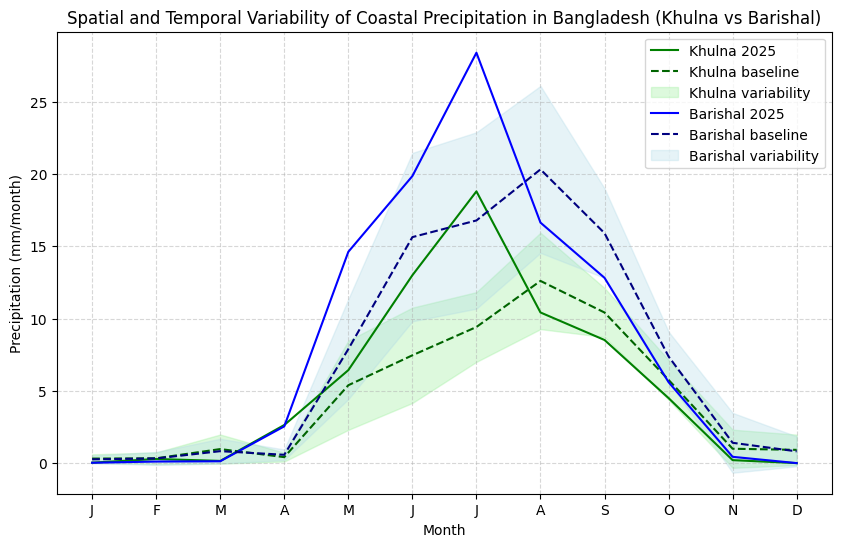

In [ ]:
months = np.arange(1,13)
plt.figure(figsize=(10,6))

# Khulna
plt.plot(months, tp_khulna_2025, label="Khulna 2025", color="green")
plt.plot(months, tp_khulna_baseline, linestyle="--", color="darkgreen", label="Khulna baseline")
plt.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Khulna variability")

# Barishal
plt.plot(months, tp_barishal_2025, label="Barishal 2025", color="blue")
plt.plot(months, tp_barishal_baseline, linestyle="--", color="navy", label="Barishal baseline")
plt.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Barishal variability")

# Axis setup
plt.xticks(months, ["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.ylabel("Precipitation (mm/month)")
plt.xlabel("Month")
plt.title("Spatial and Temporal Variability of Coastal Precipitation in Bangladesh (Khulna vs Barishal)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# --- Load ERA5 dataset ---
ds = xr.open_dataset("data_stream-moda_stepType-avgad.nc")

# Convert ERA5 'tp' (m/day) → mm/month
tp = ds['tp'] * 1000 * 365.25 / 12.0

# --- Baseline climatology (2021–2024) ---
baseline = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").mean(dim="valid_time")
std = tp.sel(valid_time=slice("2021-01-01","2024-12-31")).groupby("valid_time.month").std(dim="valid_time")

# --- Region masks ---
lats = ds.latitude.values
lons = ds.longitude.values
lon2d, lat2d = np.meshgrid(lons, lats)

mask_khulna = ((lat2d >= 21.5) & (lat2d <= 23.0) &
               (lon2d >= 88.5) & (lon2d <= 90.0)).astype(int)

mask_barishal = ((lat2d >= 21.0) & (lat2d <= 23.0) &
                 (lon2d >= 90.0) & (lon2d <= 91.5)).astype(int)

mask_ds = xr.Dataset(
    {
        "mask_khulna": (("latitude","longitude"), mask_khulna),
        "mask_barishal": (("latitude","longitude"), mask_barishal),
    },
    coords={"latitude": lats, "longitude": lons}
)

# --- Function to compute yearly averages for a region ---
def region_yearly(tp, mask, year):
    tp_year = tp.sel(valid_time=slice(f"{year}-01-01", f"{year}-12-31")).groupby("valid_time.month").mean(dim="valid_time")
    return (tp_year * mask).mean(dim=['latitude','longitude'])

# --- Compute yearly series for Khulna and Barishal ---
years = [2021, 2022, 2023, 2024, 2025]
khulna_series = {year: region_yearly(tp, mask_ds['mask_khulna'], year) for year in years}
barishal_series = {year: region_yearly(tp, mask_ds['mask_barishal'], year) for year in years}

# --- Baseline averages ---
tp_khulna_baseline = (baseline * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_khulna_std = (std * mask_ds['mask_khulna']).mean(dim=['latitude','longitude'])
tp_barishal_baseline = (baseline * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])
tp_barishal_std = (std * mask_ds['mask_barishal']).mean(dim=['latitude','longitude'])

# --- Plot side by side ---
months = np.arange(1,13)
labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Khulna plot
for year, data in khulna_series.items():
    ax1.plot(months, data, label=f"{year}", alpha=0.8)
ax1.plot(months, tp_khulna_baseline, color="black", linestyle="--", label="Baseline (2021–2024)")
ax1.fill_between(months,
                 tp_khulna_baseline - tp_khulna_std,
                 tp_khulna_baseline + tp_khulna_std,
                 color="lightgreen", alpha=0.3, label="Variability (±1σ)")
ax1.set_xticks(months)
ax1.set_xticklabels(labels)
ax1.set_title("Khulna: Yearly Monthly Rainfall vs Baseline")
ax1.set_ylabel("Precipitation (mm/month)")
ax1.set_xlabel("Month")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=8)

# Barishal plot
for year, data in barishal_series.items():
    ax2.plot(months, data, label=f"{year}", alpha=0.8)
ax2.plot(months, tp_barishal_baseline, color="black", linestyle="--", label="Baseline (2021–2024)")
ax2.fill_between(months,
                 tp_barishal_baseline - tp_barishal_std,
                 tp_barishal_baseline + tp_barishal_std,
                 color="lightblue", alpha=0.3, label="Variability (±1σ)")
ax2.set_xticks(months)
ax2.set_xticklabels(labels)
ax2.set_title("Barishal: Yearly Monthly Rainfall vs Baseline")
ax2.set_xlabel("Month")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("khulna_barishal_yearly_vs_baseline.png", dpi=300)
plt.show()


# New Section